In [1]:
import sys, pathlib
sys.path.insert(0, str(next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "dataset_config.py").exists())))
from dataset_config import RAW_DIR, FINAL_DIR

### Analysing both datasets before Data Augmentation

In [2]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict

def get_category_distribution(dataset_path):
    """Counts the number of images per category (each subfolder represents a category)"""
    category_counts = {}
    
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            category_counts[category] = len(os.listdir(category_path))
    
    return category_counts

def get_plant_distribution(category_counts):
    """Groups categories into plants by extracting plant names from folder names"""
    plant_counts = defaultdict(int)

    for category, count in category_counts.items():
        plant_name = category.split('_')[0]  # Extract plant name (before '_')
        plant_counts[plant_name] += count  # Sum all related categories
    
    return dict(plant_counts)

def plot_distribution(data, title, xlabel, ylabel):
    """Plots a bar chart in descending order"""
    sorted_data = sorted(data.items(), key=lambda x: x[1], reverse=True)  # Sort descending
    labels, counts = zip(*sorted_data)

    plt.figure(figsize=(12, 6))
    plt.bar(labels, counts, color='skyblue')
    plt.xticks(rotation=75, ha='right')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


📊 Analyzing PlantVillage Dataset...

🔹 PlantVillage Imbalanced - Categories: {'Apple___Apple_scab': 1000, 'Apple___Black_rot': 1000, 'Apple___Cedar_apple_rust': 1000, 'Apple___healthy': 1645, 'Background_without_leaves': 1143, 'Blueberry___healthy': 1502, 'Cherry___healthy': 1000, 'Cherry___Powdery_mildew': 1052, 'Corn___Cercospora_leaf_spot Gray_leaf_spot': 1000, 'Corn___Common_rust': 1192, 'Corn___healthy': 1162, 'Corn___Northern_Leaf_Blight': 1000, 'Grape___Black_rot': 1180, 'Grape___Esca_(Black_Measles)': 1383, 'Grape___healthy': 1000, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 1076, 'Orange___Haunglongbing_(Citrus_greening)': 5507, 'Peach___Bacterial_spot': 2297, 'Peach___healthy': 1000, 'Pepper,_bell___Bacterial_spot': 1000, 'Pepper,_bell___healthy': 1478, 'Potato___Early_blight': 1000, 'Potato___healthy': 1000, 'Potato___Late_blight': 1000, 'Raspberry___healthy': 1000, 'Soybean___healthy': 5090, 'Squash___Powdery_mildew': 1835, 'Strawberry___healthy': 1000, 'Strawberry___Lea

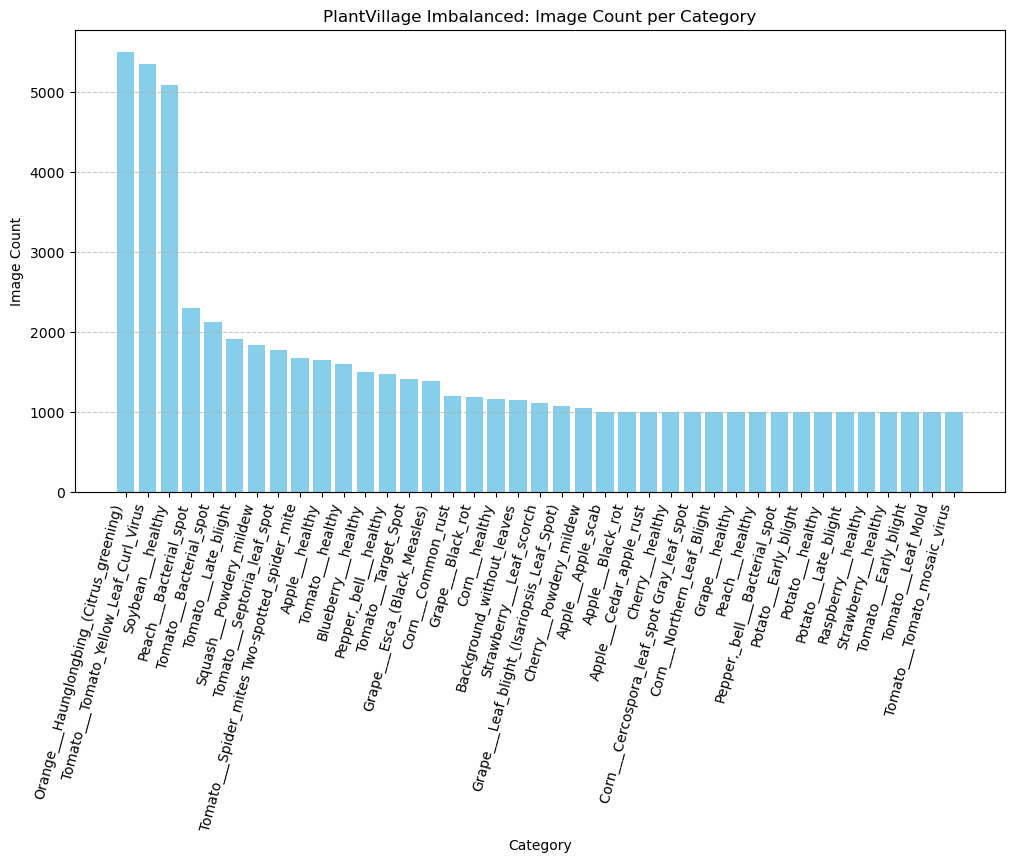

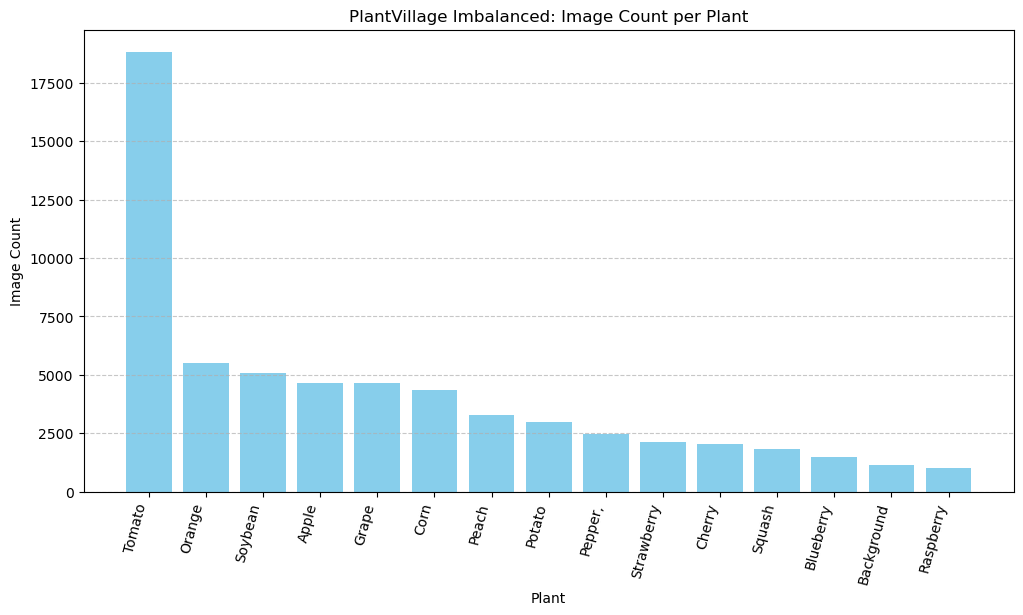

In [3]:
# Change these paths to the correct dataset directories on your system
plantvillage_path = str(RAW_DIR / "plantvillage_raw")

if __name__ == "__main__":
    # Analyzing PlantVillage
    print("\n📊 Analyzing PlantVillage Dataset...")
    pv_category_counts = get_category_distribution(plantvillage_path)
    pv_plant_counts = get_plant_distribution(pv_category_counts)

    print("\n🔹 PlantVillage Imbalanced - Categories:", pv_category_counts)
    print("\n🔹 PlantVillage Imbalanced - Plants:", pv_plant_counts)

    plot_distribution(pv_category_counts, "PlantVillage Imbalanced: Image Count per Category", "Category", "Image Count")
    plot_distribution(pv_plant_counts, "PlantVillage Imbalanced: Image Count per Plant", "Plant", "Image Count")

In [4]:
# Change these paths to the correct dataset directories on your system
npd_unbalanced_path = "../All_Datasets/New Plant Diseases Dataset(Unbalanced)"

if __name__ == "__main__":
    # Analyzing New Plant Disease Dataset
    print("\n📊 Analyzing New Plant Diseaase Unbalanced...")
    npd_category_counts = get_category_distribution(npd_unbalanced_path)
    npd_plant_counts = get_plant_distribution(npd_category_counts)

    print("\n🔹 New Plant Imbalanced - Categories:", npd_category_counts)
    print("\n🔹 New Plant Imbalanced - Plants:", npd_plant_counts)

    plot_distribution(npd_category_counts, "New Plant Imbalanced: Image Count per Category", "Category", "Image Count")
    plot_distribution(npd_plant_counts, "New Plant Imbalanced: Image Count per Plant", "Plant", "Image Count")


📊 Analyzing New Plant Diseaase Unbalanced...


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../All_Datasets/New Plant Diseases Dataset(Unbalanced)'

### Analysis for the dataset After Balancing

In [5]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict

def get_category_distribution(dataset_path):
    """Counts the number of images per category (each subfolder represents a category)"""
    category_counts = {}
    
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            category_counts[category] = len(os.listdir(category_path))
    
    return category_counts

def get_plant_distribution(category_counts):
    """Groups categories into plants by extracting plant names from folder names"""
    plant_counts = defaultdict(int)

    for category, count in category_counts.items():
        plant_name = category.split('_')[0]  # Extract plant name (before '_')
        plant_counts[plant_name] += count  # Sum all related categories
    
    return dict(plant_counts)

def plot_distribution(data, title, xlabel, ylabel):
    """Plots a bar chart sorted alphabetically by the label"""
    # Sorted alphabetically by key (label)
    sorted_data = sorted(data.items(), key=lambda x: x[0])
    labels, counts = zip(*sorted_data)

    plt.figure(figsize=(12, 6))
    plt.bar(labels, counts, color='skyblue')
    plt.xticks(rotation=75, ha='right')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### New Plant Diseases Dataset 

#### Having one folder for train and valid


📊 Analyzing New Plant Disease Balanced...

🔹 New Plant Balanced - Categories: {'Apple___Apple_scab': 2300, 'Apple___Black_rot': 2300, 'Apple___Cedar_apple_rust': 2300, 'Apple___healthy': 2300, 'Blueberry___healthy': 2300, 'Cherry_(including_sour)___healthy': 2300, 'Cherry_(including_sour)___Powdery_mildew': 2300, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 2300, 'Corn_(maize)___Common_rust_': 2300, 'Corn_(maize)___healthy': 2300, 'Corn_(maize)___Northern_Leaf_Blight': 2300, 'Grape___Black_rot': 2300, 'Grape___Esca_(Black_Measles)': 2300, 'Grape___healthy': 2300, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 2300, 'Orange___Haunglongbing_(Citrus_greening)': 2300, 'Peach___Bacterial_spot': 2300, 'Peach___healthy': 2300, 'Pepper,_bell___Bacterial_spot': 2300, 'Pepper,_bell___healthy': 2300, 'Potato___Early_blight': 2300, 'Potato___healthy': 2300, 'Potato___Late_blight': 2300, 'Raspberry___healthy': 2300, 'Soybean___healthy': 2300, 'Squash___Powdery_mildew': 2300, 'Strawberry___

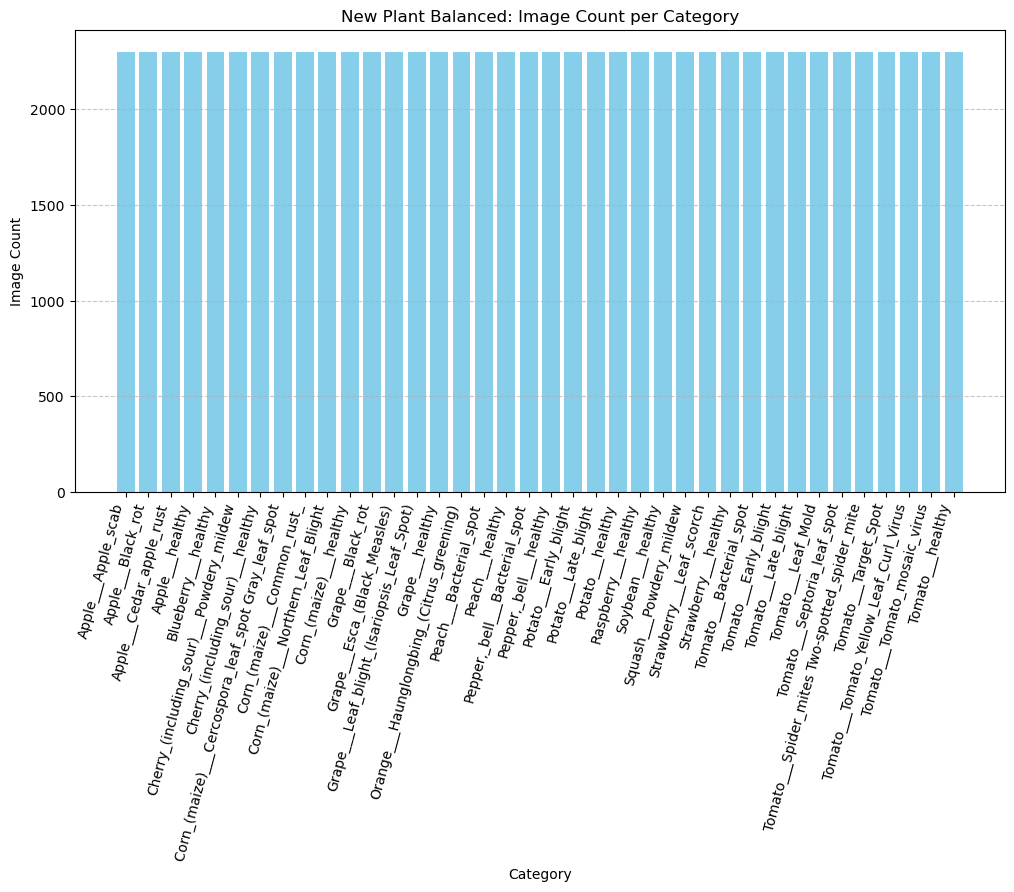

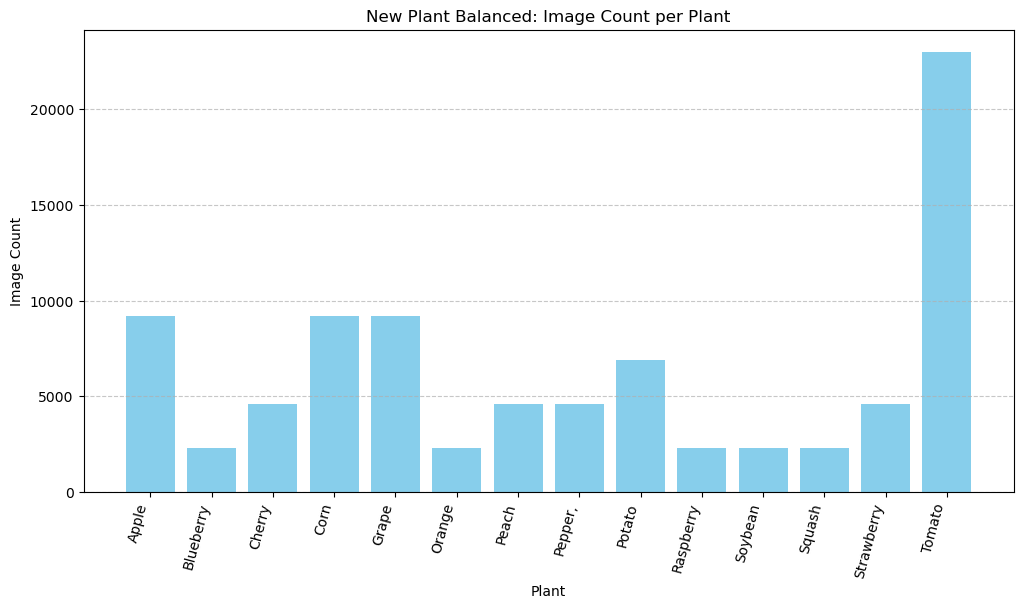

In [6]:
# Change these paths to the correct dataset directories on your system
plantvillage_balanced_path = str(FINAL_DIR / "new_plant_diseases_balanced")

if __name__ == "__main__":
    # Analyzing New Plant Disease Dataset
    print("\n📊 Analyzing New Plant Disease Balanced...")
    npd_category_counts = get_category_distribution(plantvillage_balanced_path)
    npd_plant_counts = get_plant_distribution(npd_category_counts)

    print("\n🔹 New Plant Balanced - Categories:", npd_category_counts)
    print("\n🔹 New Plant Balanced - Plants:", npd_plant_counts)

    plot_distribution(npd_category_counts, "New Plant Balanced: Image Count per Category", "Category", "Image Count")
    plot_distribution(npd_plant_counts, "New Plant Balanced: Image Count per Plant", "Plant", "Image Count")

#### Having train and valid differently

In [7]:
# Change these paths to the correct dataset directories on your system
plantvillage_balanced_path = "../All_Datasets/New Plant Diseases Dataset (Balanced)/train"

if __name__ == "__main__":
    # Analyzing New Plant Disease Dataset
    print("\n📊 Analyzing PlantVillage Balanced...")
    npd_category_counts = get_category_distribution(plantvillage_balanced_path)
    npd_plant_counts = get_plant_distribution(npd_category_counts)

    print("\n🔹 New Plant Balanced - Categories:", npd_category_counts)
    print("\n🔹 New Plant Balanced - Plants:", npd_plant_counts)

    plot_distribution(npd_category_counts, "New Plant Balanced: Image Count per Category", "Category", "Image Count")
    plot_distribution(npd_plant_counts, "New Plant Balanced: Image Count per Plant", "Plant", "Image Count")


📊 Analyzing PlantVillage Balanced...


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../All_Datasets/New Plant Diseases Dataset (Balanced)/train'

In [8]:
# Change these paths to the correct dataset directories on your system
plantvillage_balanced_path = "../All_Datasets/New Plant Diseases Dataset (Balanced)/valid"

if __name__ == "__main__":
    # Analyzing New Plant Disease Dataset
    print("\n📊 Analyzing PlantVillage Balanced...")
    npd_category_counts = get_category_distribution(plantvillage_balanced_path)
    npd_plant_counts = get_plant_distribution(npd_category_counts)

    print("\n🔹 New Plant Balanced - Categories:", npd_category_counts)
    print("\n🔹 New Plant Balanced - Plants:", npd_plant_counts)

    plot_distribution(npd_category_counts, "New Plant Balanced: Image Count per Category", "Category", "Image Count")
    plot_distribution(npd_plant_counts, "New Plant Balanced: Image Count per Plant", "Plant", "Image Count")


📊 Analyzing PlantVillage Balanced...


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../All_Datasets/New Plant Diseases Dataset (Balanced)/valid'

In [9]:
# Change these paths to the correct dataset directories on your system
plantvillage_balanced_path = "../All_Datasets/New Plant Diseases Dataset (Balanced)/combine"

if __name__ == "__main__":
    # Analyzing New Plant Disease Dataset
    print("\n📊 Analyzing PlantVillage Balanced...")
    npd_category_counts = get_category_distribution(plantvillage_balanced_path)
    npd_plant_counts = get_plant_distribution(npd_category_counts)

    print("\n🔹 New Plant Balanced - Categories:", npd_category_counts)
    print("\n🔹 New Plant Balanced - Plants:", npd_plant_counts)

    plot_distribution(npd_category_counts, "New Plant Balanced: Image Count per Category", "Category", "Image Count")
    plot_distribution(npd_plant_counts, "New Plant Balanced: Image Count per Plant", "Plant", "Image Count")


📊 Analyzing PlantVillage Balanced...


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../All_Datasets/New Plant Diseases Dataset (Balanced)/combine'

### PlantVillage


📊 Analyzing PlantVillage Balanced...



🔹 PlantVillage Balanced - Categories: {'Apple___Apple_scab': 1999, 'Apple___Black_rot': 2000, 'Apple___Cedar_apple_rust': 2000, 'Apple___healthy': 2000, 'Background_without_leaves': 2000, 'Blueberry___healthy': 2000, 'Cherry___healthy': 2000, 'Cherry___Powdery_mildew': 2000, 'Corn___Cercospora_leaf_spot Gray_leaf_spot': 2000, 'Corn___Common_rust': 1999, 'Corn___healthy': 2000, 'Corn___Northern_Leaf_Blight': 2000, 'Grape___Black_rot': 2000, 'Grape___Esca_(Black_Measles)': 2000, 'Grape___healthy': 2000, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 2000, 'Orange___Haunglongbing_(Citrus_greening)': 2000, 'Peach___Bacterial_spot': 2000, 'Peach___healthy': 2000, 'Pepper,_bell___Bacterial_spot': 2000, 'Pepper,_bell___healthy': 2000, 'Potato___Early_blight': 2000, 'Potato___healthy': 2000, 'Potato___Late_blight': 2000, 'Raspberry___healthy': 2000, 'Soybean___healthy': 2000, 'Squash___Powdery_mildew': 2000, 'Strawberry___healthy': 2000, 'Strawberry___Leaf_scorch': 2000, 'Tomato___Bacterial_sp

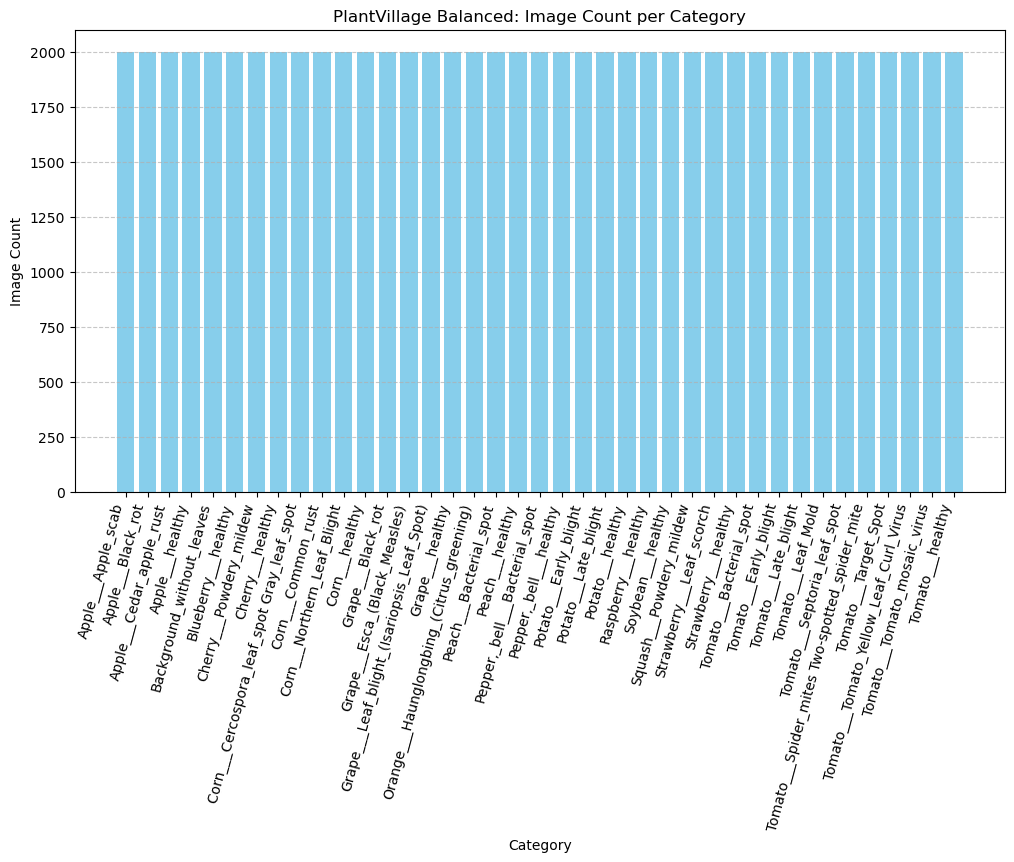

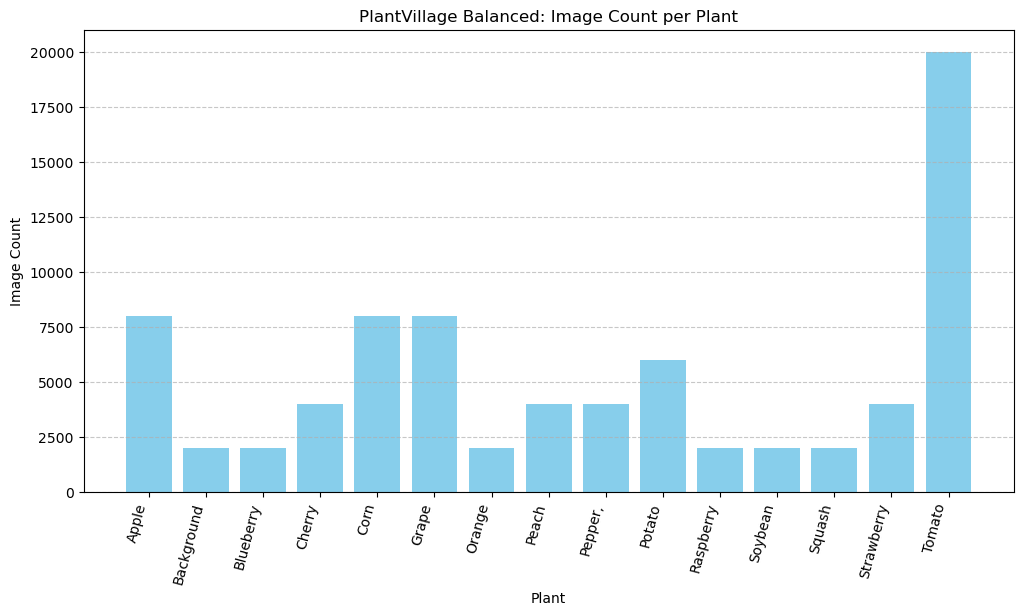

In [10]:
# Change these paths to the correct dataset directories on your system
plantvillage_path = str(RAW_DIR / "plantvillage_raw")   
plantvillage_balanced_path = str(FINAL_DIR / "plantvillage_balanced")


if __name__ == "__main__":
    # Analyzing New Plant Disease Dataset
    print("\n📊 Analyzing PlantVillage Balanced...")
    npd_category_counts = get_category_distribution(plantvillage_balanced_path)
    npd_plant_counts = get_plant_distribution(npd_category_counts)

    print("\n🔹 PlantVillage Balanced - Categories:", npd_category_counts)
    print("\n🔹 PlantVillage Balanced - Plants:", npd_plant_counts)

    plot_distribution(npd_category_counts, "PlantVillage Balanced: Image Count per Category", "Category", "Image Count")
    plot_distribution(npd_plant_counts, "PlantVillage Balanced: Image Count per Plant", "Plant", "Image Count")



📊 Analyzing PlantVillage Balanced...

🔹 PlantVillage Balanced - Categories: {'Apple___Apple_scab': 833, 'Apple___Black_rot': 833, 'Apple___Cedar_apple_rust': 833, 'Apple___healthy': 2500, 'Background_without_leaves': 5000, 'Blueberry___healthy': 5000, 'Cherry___healthy': 2500, 'Cherry___Powdery_mildew': 2500, 'Corn___Cercospora_leaf_spot Gray_leaf_spot': 833, 'Corn___Common_rust': 833, 'Corn___healthy': 2500, 'Corn___Northern_Leaf_Blight': 833, 'Grape___Black_rot': 833, 'Grape___Esca_(Black_Measles)': 833, 'Grape___healthy': 2500, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 833, 'Orange___Haunglongbing_(Citrus_greening)': 5000, 'Peach___Bacterial_spot': 2500, 'Peach___healthy': 2500, 'Pepper,_bell___Bacterial_spot': 2500, 'Pepper,_bell___healthy': 2500, 'Potato___Early_blight': 1250, 'Potato___healthy': 2500, 'Potato___Late_blight': 1250, 'Raspberry___healthy': 5000, 'Soybean___healthy': 5000, 'Squash___Powdery_mildew': 5000, 'Strawberry___healthy': 2500, 'Strawberry___Leaf_scorch':

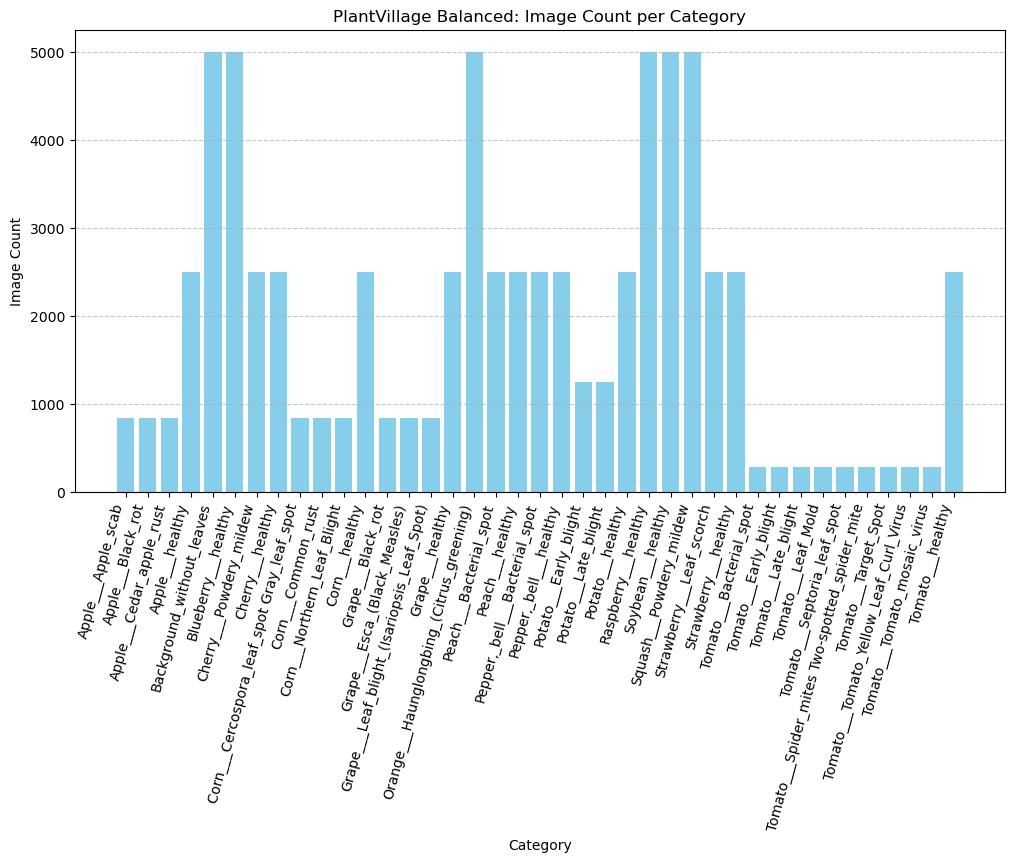

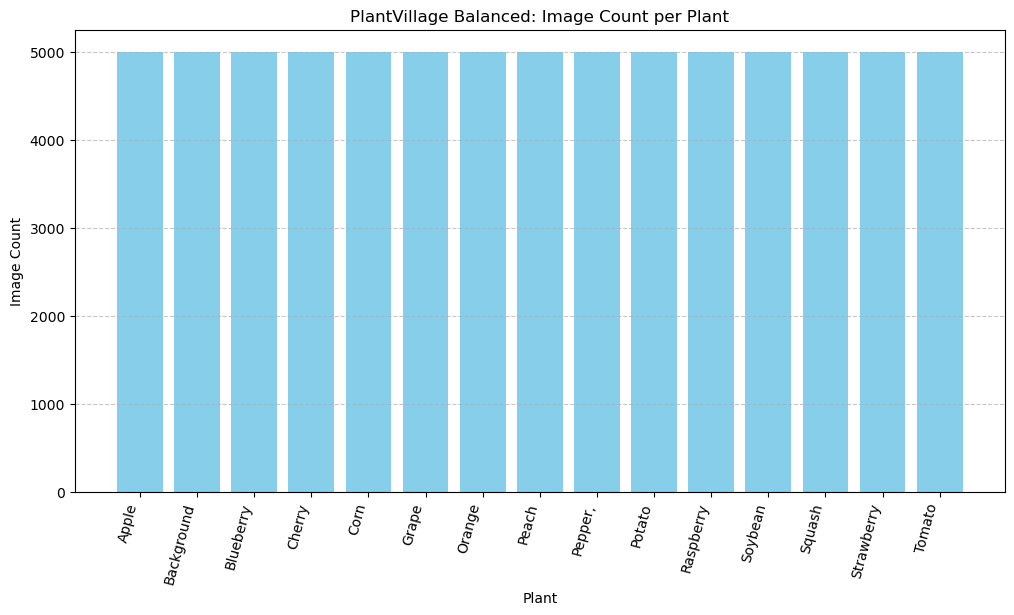

In [11]:
# Change these paths to the correct dataset directories on your system
plantvillage_path = str(RAW_DIR / "plantvillage_raw")   
plantvillage_balanced_path = str(FINAL_DIR / "plantvillage_balanced_by_plant")

if __name__ == "__main__":
    # Analyzing New Plant Disease Dataset
    print("\n📊 Analyzing PlantVillage Balanced...")
    npd_category_counts = get_category_distribution(plantvillage_balanced_path)
    npd_plant_counts = get_plant_distribution(npd_category_counts)

    print("\n🔹 PlantVillage Balanced - Categories:", npd_category_counts)
    print("\n🔹 PlantVillage Balanced - Plants:", npd_plant_counts)

    plot_distribution(npd_category_counts, "PlantVillage Balanced: Image Count per Category", "Category", "Image Count")
    plot_distribution(npd_plant_counts, "PlantVillage Balanced: Image Count per Plant", "Plant", "Image Count")